C:\Users\Sukaladevi\AppData\Local\Temp\ipykernel_19688\4204206863.py:11: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')


✅ Data inserted successfully!


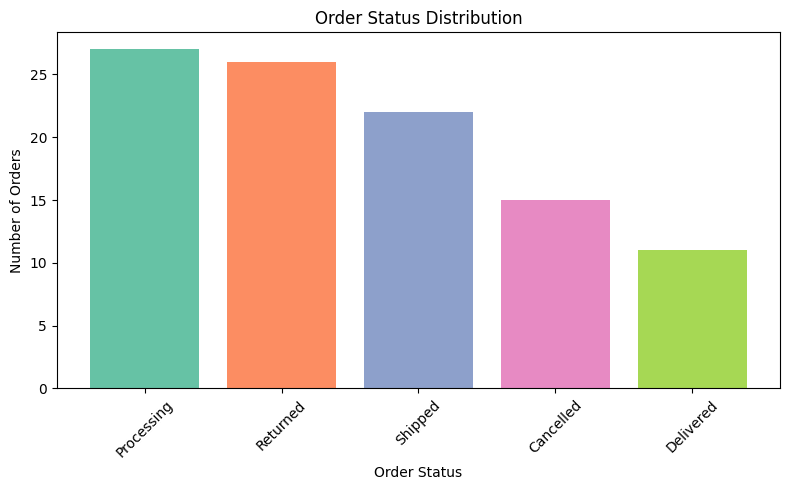

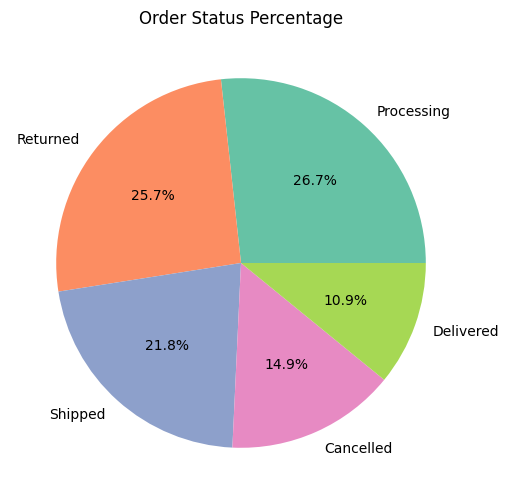

In [5]:
import pandas as pd
import mysql.connector

# 1. Load CSV
df = pd.read_csv("C:/Users/Sukaladevi/OneDrive/Desktop/namrata/ECOM.csv")

# 2. Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

# 3. Convert date safely
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

# 4. Remove bad date rows
df = df.dropna(subset=['Order_Date'])

# 5. Convert date to MySQL format
df['Order_Date'] = df['Order_Date'].dt.strftime('%Y-%m-%d')

# 6. Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="namrata16",
    database="midb"
)

cursor = conn.cursor()

# 7. Insert data safely
for _, row in df.iterrows():
    cursor.execute("""
        INSERT INTO ecommerceee
        (ID, Customer_Name, Order_ID, Order_Date, Product, Category, Quantity, Price, Payment_Method, Status, Total)
        VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
    """, (
        int(row['ID']),
        str(row['Customer_Name']),
        str(row['Order_ID']),
        row['Order_Date'],
        str(row['Product']),
        str(row['Category']),

        int(row['Quantity']) if str(row['Quantity']).isdigit() else None,
float(row['Price']) if str(row['Price']).replace('.', '', 1).isdigit() else None,
str(row['Payment_Method']),
str(row['Status']),
float(row['Total']) if str(row['Total']).replace('.', '', 1).isdigit() else None
    ))

conn.commit()
cursor.close()
conn.close()

print("✅ Data inserted successfully!")
import matplotlib.pyplot as plt

# ------------------------
# Chart Representation
# ------------------------

# Count of each order status
status_counts = df['Status'].value_counts()

# 1️⃣ Bar Chart
plt.figure(figsize=(8,5))
plt.bar(status_counts.index, status_counts.values, color=['#66c2a5','#fc8d62','#8da0cb','#e78ac3','#a6d854'])
plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("order_status_bar.png", dpi=300)  # Saves chart
plt.show()

# 2️⃣ Pie Chart
plt.figure(figsize=(6,6))
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', colors=['#66c2a5','#fc8d62','#8da0cb','#e78ac3','#a6d854'])
plt.title('Order Status Percentage')
plt.savefig("order_status_pie.png", dpi=300)
plt.show()

In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
